# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Ridho Aditya Rosman Eka Putra
- Email: ridhoaditya925@gmail.com
- Id Dicoding: b_igloo

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# import library
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

### Menyiapkan data yang akan diguankan

In [2]:
# load dataset
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
# cek info dataset dan missing value
print('ukuran dataset:', df.shape)
print('missing value:', df.isnull().sum().sum())
df.info()

ukuran dataset: (4424, 37)
missing value: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualificati

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


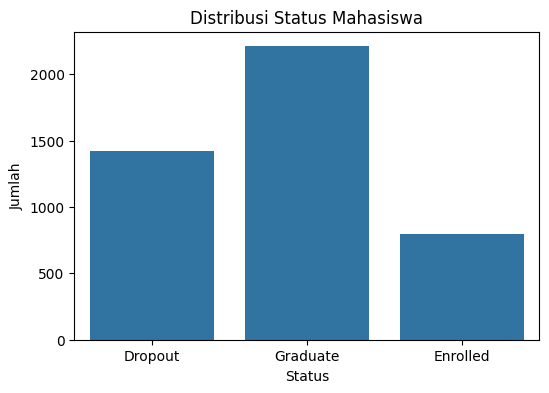

In [4]:
# cek distribusi status kelulusan
print(df['Status'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Status')
plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.show()

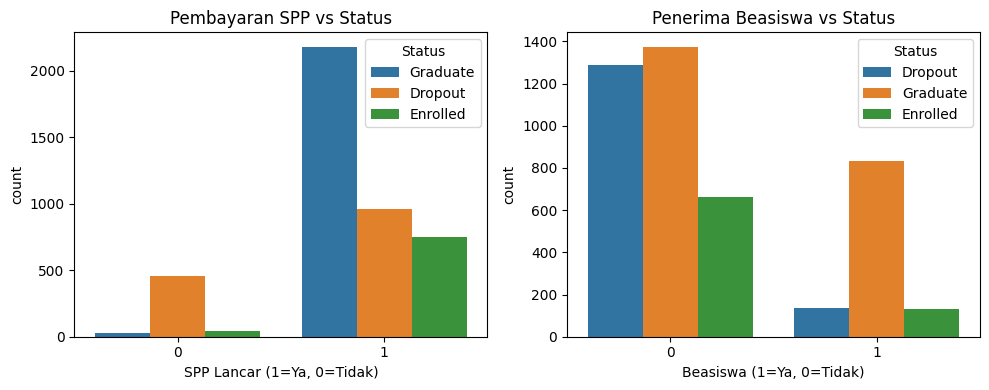

In [5]:
# visualisasi hubungan spp dan beasiswa terhadap status
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', ax=axes[0])
axes[0].set_title('Pembayaran SPP vs Status')
axes[0].set_xlabel('SPP Lancar (1=Ya, 0=Tidak)')

sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[1])
axes[1].set_title('Penerima Beasiswa vs Status')
axes[1].set_xlabel('Beasiswa (1=Ya, 0=Tidak)')

plt.tight_layout()
plt.show()

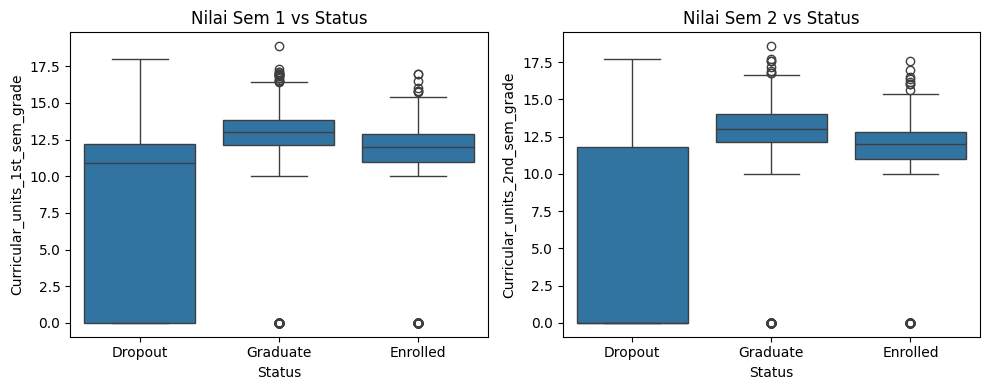

In [6]:
# visualisasi nilai semester 1 dan 2 terhadap status
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', ax=axes[0])
axes[0].set_title('Nilai Sem 1 vs Status')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', ax=axes[1])
axes[1].set_title('Nilai Sem 2 vs Status')

plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

In [7]:
# filtering dataset: hanya siswa Dropout dan Graduate
# data Enrolled disimpan untuk nanti
df_enrolled = df[df['Status'] == 'Enrolled'].copy()
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

# buat target biner (1=Dropout, 0=Graduate)
X = df_model.drop(columns=['Status'])
y = (df_model['Status'] == 'Dropout').astype(int)

print('\nVerifikasi distribusi target:')
print(y.value_counts(normalize=True))
print('\nJumlah sampel per kelas target (0=Graduate, 1=Dropout):')
print(y.value_counts())


Verifikasi distribusi target:
Status
0    0.60854
1    0.39146
Name: proportion, dtype: float64

Jumlah sampel per kelas target (0=Graduate, 1=Dropout):
Status
0    2209
1    1421
Name: count, dtype: int64


In [8]:
# split data train dan test 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('dimensi train:', X_train.shape)
print('dimensi test:', X_test.shape)

dimensi train: (2904, 36)
dimensi test: (726, 36)


In [9]:
# standarisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

In [10]:
# latih model logistic regression dan random forest
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Evaluation

In [11]:
# evaluasi model logistic regression
y_pred_lr = model_lr.predict(X_test_scaled)
print('=== Evaluasi Logistic Regression ===')
print('Akurasi:', accuracy_score(y_test, y_pred_lr))
print('Recall:', recall_score(y_test, y_pred_lr))
print('F1-Score:', f1_score(y_test, y_pred_lr))
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr))

=== Evaluasi Logistic Regression ===
Akurasi: 0.9421487603305785
Recall: 0.9190140845070423
F1-Score: 0.925531914893617

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       442
           1       0.93      0.92      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



In [12]:
# evaluasi model random forest
y_pred_rf = model_rf.predict(X_test)
print('=== Evaluasi Random Forest ===')
print('Akurasi:', accuracy_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1-Score:', f1_score(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

=== Evaluasi Random Forest ===
Akurasi: 0.9214876033057852
Recall: 0.8802816901408451
F1-Score: 0.8976660682226212

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94       442
           1       0.92      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



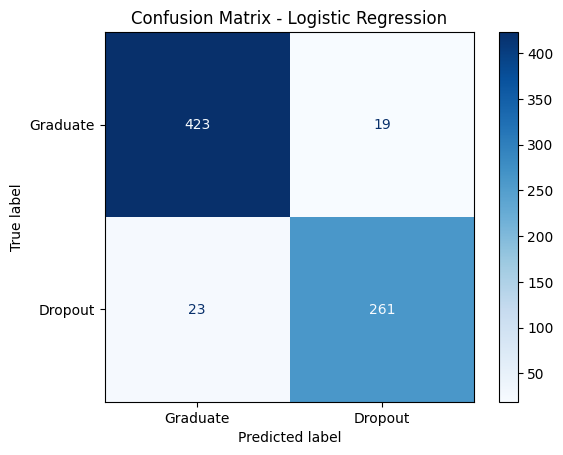

In [13]:
# tampilkan confusion matrix logistic regression
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Graduate', 'Dropout'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [14]:
# simpan model terbaik dan scaler
os.makedirs('model', exist_ok=True)
joblib.dump(model_lr, 'model/model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(list(X.columns), 'model/features.pkl')

['model/features.pkl']